In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [181]:
# defined weightage
weights = {
    "midterm1": 0.25,
    "midterm2": 0.25,
    "final_exam": 0.40,
    "attendance": 0.10,
}

In [182]:
# function to print welcome screen
def show_intro():
    print("\n==============================================")
    print("        STUDENT GRADE MANAGEMENT SYSTEM")
    print("==============================================")
    print("This program allows instructors to enter, load,")
    print("analyze, and visualize student grade data.")
    print("\nFeatures include:")
    print(" - Manual data entry for student scores")
    print(" - Loading grade data from CSV files")
    print(" - Calculating weighted total scores")
    print(" - Assigning letter grades")
    print(" - Summary statistics and analytics")
    print(" - Histograms and grade distribution charts")
    print(" - Exporting final results to CSV")
    print("\nDesigned to support instructors in managing")
    print("class performance efficiently and accurately.")
    print("==============================================\n")

In [183]:
# function to prompt user the mode
def ask_start_mode():
    print("\n==============================================")
    print("    How would you like to start?")
    print("==============================================")
    print("1. Import existing processed grade summary (e.g., grade_summary.csv)")
    print("2. Start fresh and load/process new subject scores")
    print("3. Exit.")
    print("==============================================")

    while True:
        choice = input("Enter 1, 2 or 3: ").strip()
        if choice in ["1", "2", "3"]:
            return choice
        print("Invalid choice.")


In [184]:
# function to print out main menu options
def print_menu():
    print("\nGrade Management System\n")
    print("1. Enter new student data (manual)")
    print("2. Load data from CSV file(s)")
    print("3. Show summary statistics (per subject + combined)")
    print("4. Plot score distribution (per subject, TotalScore)")
    print("5. Plot letter grade pie chart (per subject)")
    print("6. Search student details by Roll Number")
    print("7. Export grade summaries per subject to CSV")
    print("0. Exit")

In [185]:
# function to display the analysis menu options
def print_analysis_menu():
    print("\nGrade Management System – Analysis Mode\n")
    print("1. Show summary statistics (per subject + combined)")
    print("2. Plot score distribution (per subject, TotalScore)")
    print("3. Plot letter grade pie chart (per subject)")
    print("4. Search student details by Roll Number")
    print("0. Go to main menu")

In [186]:
# function to load csv
def load_csv(filename):
  try:
    df = pd.read_csv(filename)
    return df
  except FileNotFoundError:
    print(f"Error: File {filename} not found")
  except Exception as e:
    print(f"Error reading {e}")
  return None

In [187]:
# function to promt use scores
def score_input(output):
    while True:
        try:
            value = float(input(output))
            if 0 <= value <= 100:
                return value
            else:
                print("Error: Please enter a number between 0 and 100.")
        except ValueError:
            print("Error: Invalid number. Please enter a numeric value.")

In [188]:
# function to export data into csv
def export_to_csv(df, filename="grade_summary.csv"):
    try:
        export_df = df.copy()

        internal_cols = ["Threshold", "TotalClasses"]

        export_df = export_df.drop(columns=[col for col in internal_cols if col in export_df.columns],errors="ignore")

        export_df.to_csv(filename, index=False)

        print(f"Data exported to '{filename}'.")
    except Exception as e:
        print(f"Error exporting to CSV: {e}")


In [189]:
# function to calculate total score and attendence based on missing classes
def calculate_total_score_attendence(row):
    total_classes = row["TotalClasses"]
    missing = row["Missing Classes"]
    threshold = row["Threshold"]

    if missing <= threshold:
        attendance_score = 100
    else:
        attendance_score = max(
            0, ((total_classes - missing) / total_classes) * 100
        )

    total = (
        row["Midterm_1"] * weights["midterm1"]
        + row["Midterm_2"] * weights["midterm2"]
        + row["Final_Exam"] * weights["final_exam"]
        + attendance_score * weights["attendance"]
    )

    return pd.Series({
        "TotalScore": total,
        "AttendanceScore": attendance_score
    })


In [190]:
# function to map/assign grades based on thier scores
def assign_letter_grade(score):
    if score >= 90:
        return "A"
    elif score >= 80:
        return "B"
    elif score >= 70:
        return "C"
    elif score >= 60:
        return "D"
    else:
        return "F"

In [191]:
# function to add totals and grades
def add_totals_and_grades(df):

    if df is None or df.empty:
        print("Data is empty.")
        return df

    required_cols = [
        "Midterm_1",
        "Midterm_2",
        "Final_Exam",
        "Missing Classes",
        "TotalClasses",
        "Threshold",
    ]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(
                f"Missing column '{col}' in data. Columns found: {list(df.columns)}"
            )
    df[["TotalScore", "AttendanceScore"]] = df.apply(
        calculate_total_score_attendence, axis=1
    )

    df["TotalScore"] = df["TotalScore"].round(2)
    df["AttendanceScore"] = df["AttendanceScore"].round(2)

    df["LetterGrade"] = df["TotalScore"].apply(assign_letter_grade)

    print("Total scores and letter grades have been calculated.")
    return df


In [192]:
# function to show the summary statistics
def show_summary_statistics(df, title=None):
    if df is None or df.empty:
        print("No data available for summary statistics.")
        return

    cols = ["Midterm_1", "Midterm_2", "Final_Exam"]
    if "TotalScore" in df.columns:
        cols.append("TotalScore")

    if title:
        print(f"\nSUMMARY STATISTICS: {title}")
    else:
        print("\nSUMMARY STATISTICS")

    print("\nBasic Statistics\n")
    print(df[cols].describe().transpose())

    print("\nAdditional Metrics\n")
    print(f"Number of Students: {len(df)}")

    if "TotalScore" in df.columns:
        print(f"Class Average (TotalScore): {df['TotalScore'].mean():.2f}")
        print(f"Class Median (TotalScore): {df['TotalScore'].median():.2f}")
        iqr = df["TotalScore"].quantile(0.75) - df["TotalScore"].quantile(0.25)
        print(f"IQR (TotalScore): {iqr:.2f}")

        if "Student_Name" in df.columns:
            name_col = "Student_Name"
        elif "Name" in df.columns:
            name_col = "Name"
        else:
            name_col = None

        if name_col is not None:
            highest_idx = df["TotalScore"].idxmax()
            lowest_idx = df["TotalScore"].idxmin()

            print("\nBest and Worst Students")
            print(f"Highest Scorer: {df.loc[highest_idx, name_col]} "
                  f"({df.loc[highest_idx, 'TotalScore']:.2f})")
            print(f"Lowest Scorer: {df.loc[lowest_idx, name_col]} "
                  f"({df.loc[lowest_idx, 'TotalScore']:.2f})")

    print("\nHighest & Lowest per Exam")
    for col in cols:
        high_idx = df[col].idxmax()
        low_idx = df[col].idxmin()

        if "Student_Name" in df.columns:
            name_col = "Student_Name"
        elif "Name" in df.columns:
            name_col = "Name"
        else:
            name_col = None

        print(f"{col}:")
        if name_col is not None:
            print(f"   Highest: {df.loc[high_idx, name_col]} ({df[col].max()})")
            print(f"   Lowest : {df.loc[low_idx, name_col]} ({df[col].min()})")
        else:
            print(f"   Highest value: {df[col].max()}")
            print(f"   Lowest value : {df[col].min()}")

    if "LetterGrade" in df.columns:
        print("\nLetter Grade Distribution\n")
        print(df["LetterGrade"].value_counts().sort_index())


In [193]:
# function for showing all the statistics summary
def show_all_statistics(subjects):
    if not subjects:
        print("No subject data available.")
        return

    for subj_name, subj_df in subjects:
        show_summary_statistics(subj_df, title=f"Subject: {subj_name}")
    if len(subjects) > 1:
      all_df = pd.concat([df for _, df in subjects], ignore_index=True)
      show_summary_statistics(all_df, title="All Subjects (Combined)")

      if "Student_ID" not in all_df.columns:
          print("\n(Student_ID column not found; skipping multi-subject analysis.)")
          return

      print("\nSTUDENTS ENROLLED IN MULTIPLE SUBJECTS")

      id_counts = all_df["Student_ID"].value_counts()
      multi_ids = id_counts[id_counts > 1].index

      if len(multi_ids) == 0:
          print("No students found in more than one subject.")
          return

      print(f"Number of students in more than one subject: {len(multi_ids)}")

      multi_df = all_df[all_df["Student_ID"].isin(multi_ids)]

      print("\nDETAILED RESULTS (ALL SUBJECTS FOR MULTI-SUBJECT STUDENTS):")

      detail_cols = [
          "Student_ID",
          "Student_Name",
          "Subject",
          "Midterm_1",
          "Midterm_2",
          "Final_Exam",
          "AttendanceScore",
          "TotalScore",
          "LetterGrade",
      ]

      detail_cols = [c for c in detail_cols if c in multi_df.columns]

      detailed_table = multi_df[detail_cols].sort_values(
          by=["Student_ID", "Subject"]
      )

      print(detailed_table.to_string(index=False))

      print("\nPER-STUDENT AVERAGE STATS (ACROSS ALL THEIR SUBJECTS):")

      group_cols = ["Student_ID"]
      if "Student_Name" in multi_df.columns:
          group_cols.append("Student_Name")

      student_stats = (
          multi_df.groupby(group_cols)[["TotalScore", "AttendanceScore"]]
          .mean()
          .round(2)
      )

      print(student_stats.to_string())
    else:
      print("\n(Only one subject loaded; combined and multi-subject statistics skipped.)")


In [194]:
def collect_student_data():
    students = []
    used_ids = set() 

    while True:
        while True:
            student_id_raw = input("Student ID (numeric) or 'q' to stop: ").strip()

            if student_id_raw.lower() == "q":
                if not students:
                    print("No student data entered.")
                else:
                    print("Total scores and letter grades have been calculated.")
                return students

            try:
                student_id = int(student_id_raw)
                if student_id in used_ids:
                    print(f"Error: Student ID {student_id} has already been entered. Please use a different ID.")
                    continue
                break
            except ValueError:
                print("Error: Student ID must be a numeric value (e.g., 12345).")

        while True:
            name = input("Student Name: ").strip()

            if name == "":
                print("Error: Name cannot be empty.")
                continue

            if all(ch.isalpha() or ch.isspace() for ch in name):
                break
            else:
                print("Error: Name can only contain letters and spaces. No numbers or symbols allowed.")

        mid1 = score_input("Midterm 1 score (0-100): ")
        mid2 = score_input("Midterm 2 score (0-100): ")
        final_exam = score_input("Final Exam score (0-100): ")

        while True:
            missed_raw = input("Number of missed classes: ").strip()
            try:
                missed = int(missed_raw)
                if missed < 0:
                    print("Error: missed classes cannot be negative.")
                    continue
                break
            except ValueError:
                print("Error: please enter a valid integer (e.g., 3).")

        students.append({
            "Student_ID": student_id,
            "Student_Name": name,
            "Midterm_1": mid1,
            "Midterm_2": mid2,
            "Final_Exam": final_exam,
            "Missing Classes": missed
        })

        used_ids.add(student_id) 

        print("Student added.\n")

    return students

In [195]:
# function for searching student based on thier id
def search_student(roll_number, subjects):
    found = False
    print("\nStudent Search Result")

    for subject_name, df in subjects:
        if "Student_ID" not in df.columns:
            continue

        matches = df[df["Student_ID"].astype(str) == str(roll_number)]

        if not matches.empty:
            found = True
            print(f"\nSubject: {subject_name}")
            print(matches.to_string(index=False))

    if not found:
        print(f"\nNo record found for Roll Number: {roll_number}")

In [196]:
# option 1 - handle manual entry
def handle_manual_entry(subjects, all_data_df):
    while True:
        subject_name = input("Enter subject name (e.g., 'Data Mining'): ").strip()
        try:
            if subject_name == "":
                raise ValueError("Subject name cannot be empty.")
            for ch in subject_name:
                if not (ch.isalpha() or ch.isspace()):
                    raise ValueError("Subject name must contain only letters and spaces.")
            break
        except ValueError as e:
            print("Error:", e)
    while True:
        total_classes_input = input(f"Enter total number of classes for subject '{subject_name}': ").strip()
        try:
            total_classes = int(total_classes_input)
            if total_classes <= 0:
                print("Total classes must be a positive integer.")
                continue
            break
        except ValueError:
            print("Invalid number. Please enter an integer (e.g., 30).")
    while True:
        threshold_input = input(f"Enter allowed number of absences before penalty starts for '{subject_name}': ").strip()
        try:
            threshold = int(threshold_input)
            if threshold < 0:
                print("Threshold cannot be negative. Please enter 0 or a positive integer.")
                continue
            if threshold > total_classes:
                print(f"Threshold cannot be greater than total classes ({total_classes}). Try again.")
                continue
            break
        except ValueError:
            print("Invalid input. Please enter an integer (e.g., 5).")
    students = collect_student_data()
    if students:
        df = pd.DataFrame(students)
        df["TotalClasses"] = total_classes
        df["Threshold"] = threshold
        df = add_totals_and_grades(df)
        df["Subject"] = subject_name
        subjects.append((subject_name, df))
        all_data_df = pd.concat([sdf for _, sdf in subjects], ignore_index=True)

    return subjects, all_data_df

In [198]:
# option 2 - handle csv loading
def handle_csv_loading(subjects, all_data_df):
    loaded_any = False
    while True:
        print("\nCSV Loading Mode")
        filename = input("Enter CSV filename (or press Enter to go back to menu): ").strip()

        if filename == "":
            break

        loaded_df = load_csv(filename)

        if loaded_df is not None:
            subj_input = input(f"Enter subject name for '{filename}' (or press Enter to use filename): ").strip()
            subject_name = subj_input if subj_input else filename.rsplit(".", 1)[0]
            while True:
                total_classes_input = input(f"Enter total number of classes for subject '{subject_name}': ").strip()
                try:
                    total_classes = int(total_classes_input)
                    if total_classes <= 0:
                        print("Total classes must be a positive integer.")
                        continue
                    break
                except ValueError:
                    print("Invalid number. Please enter an integer (e.g., 30).")

            while True:
                threshold_input = input(f"Enter allowed number of absences before penalty starts for '{subject_name}': ").strip()
                try:
                    threshold = int(threshold_input)
                    if threshold < 0:
                        print("Threshold cannot be negative. Please enter 0 or a positive integer.")
                        continue
                    if threshold > total_classes:
                        print(f"Threshold cannot be greater than total classes ({total_classes}). Try again.")
                        continue
                    break
                except ValueError:
                    print("Invalid input. Please enter an integer (e.g., 5).")


            loaded_df["TotalClasses"] = total_classes
            loaded_df["Threshold"] = threshold
            loaded_df = add_totals_and_grades(loaded_df)
            loaded_df["Subject"] = subject_name


            subjects.append((subject_name, loaded_df))
            loaded_any = True

            print(f"CSV file '{filename}' loaded successfully as subject '{subject_name}'.")

            print("Do you want to upload scores of a different subject?")
            print("1. Yes")
            print("2. No")
            file_choice = input("Enter your choice: ").strip()

            if file_choice == "2":
                break
        else:
            print("CSV file could not be loaded. Please try again.")

    if loaded_any:
        all_data_df = pd.concat([df for _, df in subjects], ignore_index=True)
    else:
        print("No CSV data loaded.")

    return subjects, all_data_df

In [199]:
# option 3 - calculate totals & grades
def handle_recalculate(subjects, all_data_df):
    if not subjects:
        print("No subject data available to calculate.")
        return subjects, all_data_df

    new_subjects = []
    for subj_name, subj_df in subjects:
        subj_df = add_totals_and_grades(subj_df)
        new_subjects.append((subj_name, subj_df))

    subjects = new_subjects
    all_data_df = pd.concat([df for _, df in subjects], ignore_index=True)
    print("Calculated totals and grades for all subjects.")

    return subjects, all_data_df

In [200]:
def handle_plot_scores(subjects):

    if not subjects:
        print("No subject data available for visualization.")
        return

    col = "TotalScore"
    print("\nPlotting score distributions for each subject...")

    for subj_name, subj_df in subjects:
        print(f"\nShowing distribution for: {subj_name}")

        if col not in subj_df.columns:
            print(f"Column '{col}' not found in subject '{subj_name}'.")
            continue

        plt.figure(figsize=(8, 5))
        plt.hist(subj_df[col], bins=10, edgecolor="black", alpha=0.7, rwidth=0.7)
        plt.title(f"Distribution of {col} - {subj_name}", fontsize=14)
        plt.xlabel(f"{col} Score", fontsize=12)
        plt.ylabel("Number of Students", fontsize=12)
        plt.grid(axis="y", linestyle="--", alpha=0.5)

        plt.show()
        plt.close()

    print("Finished plotting score distributions. Returning to menu...")

In [201]:
def handle_plot_grades(subjects):
    if not subjects:
        print("No subject data available for visualization.")
        return

    print("\nPlotting letter grade pie charts for each subject...")

    for subj_name, subj_df in subjects:
        print(f"\nShowing grade distribution for: {subj_name}")

        if subj_df is None or subj_df.empty:
            print(f"No data for subject '{subj_name}'. Skipping...")
            continue

        if "LetterGrade" not in subj_df.columns:
            print(f"Letter grades not calculated yet for subject '{subj_name}'. Skipping...")
            continue

        grade_counts = subj_df["LetterGrade"].value_counts()

        plt.figure(figsize=(6, 6))
        plt.pie(
            grade_counts,
            labels=grade_counts.index,
            autopct="%1.1f%%",
            startangle=90,
            wedgeprops={"edgecolor": "black"}
        )

        plt.title(f"Letter Grade Distribution - {subj_name}", fontsize=14)
        plt.show()
        plt.close()

    print("Finished plotting grade pies. Returning to menu...")


In [202]:
# option 7 - it handles the exporting of csv
def handle_export(subjects):
    if not subjects:
        print("No subject data available to export.")
        return

    print("\nExporting grade summaries for each subject...")

    for subj_name, subj_df in subjects:
        safe_name = subj_name.replace(" ", "_")
        filename = f"grade_summary_{safe_name}.csv"

        export_to_csv(subj_df, filename=filename)
        print(f"Exported: {filename}")

    print("\nAll subject grade summaries exported successfully!")

In [204]:
def handle_import_existing_summary(subjects, all_data_df):
    print("\nImport Existing Processed Grade Summary")

    filename = input("Enter existing processed summary CSV filename (or press Enter to cancel): ").strip()

    if filename == "":
        print("No file specified. Returning to main menu.")
        return subjects, all_data_df, False

    print(f"Loading file '{filename}'...")

    df = load_csv(filename)
    if df is None:
        print("Could not load file.")
        return subjects, all_data_df, False


    print("Imported existing processed grade summary. Ready for analysis.")

    subjects = [("Imported_Summary", df)]
    all_data_df = df.copy()
    
    return subjects, all_data_df, True

In [205]:
def main():
    show_intro()
    while True:
      subjects = []
      all_data_df = pd.DataFrame()
      start_mode = ask_start_mode()
      
      if start_mode == "1":
        subjects, all_data_df,success = handle_import_existing_summary(subjects, all_data_df)

        if not success:
          continue
        print("\nLoaded processed summary. You can now analyze or visualize it.\n")

        while True:
          print_analysis_menu()
          choice = input("Enter your choice: ").strip()

          if choice == "1":
            show_all_statistics(subjects)

          elif choice == "2":
            handle_plot_scores(subjects)

          elif choice == "3":
            handle_plot_grades(subjects)

          elif choice == "4":
            roll = input("Enter Student Roll Number to search: ").strip()
            search_student(roll, subjects)

          elif choice == "0":
            break
          else:
            print("Invalid choice. Please try again.")
      elif start_mode == "2":
        while True:
            print_menu()
            print("Enter your choice: ", end="", flush=True)
            choice = input().strip()
            if choice == "1":
              subjects, all_data_df = handle_manual_entry(subjects, all_data_df)

            elif choice == "2":
              subjects, all_data_df = handle_csv_loading(subjects, all_data_df)

            elif choice == "3":
                show_all_statistics(subjects)

            elif choice == "4":
                handle_plot_scores(subjects)

            elif choice == "5":
                handle_plot_grades(subjects)

            elif choice =="6":
                roll = input("Enter Student Roll Number to search: ").strip()
                search_student(roll, subjects)

            elif choice == "7":
                handle_export(subjects)


            elif choice == "0":
                print("Go to main menu")
                break

            else:
                print("Invalid choice or option disabled after CSV load.")
      else:
        print("Thank you for using the program, Goodbye!")
        return


        STUDENT GRADE MANAGEMENT SYSTEM
This program allows instructors to enter, load,
analyze, and visualize student grade data.

Features include:
 - Manual data entry for student scores
 - Loading grade data from CSV files
 - Calculating weighted total scores
 - Assigning letter grades
 - Summary statistics and analytics
 - Histograms and grade distribution charts
 - Exporting final results to CSV

Designed to support instructors in managing
class performance efficiently and accurately.


    How would you like to start?
1. Import existing processed grade summary (e.g., grade_summary.csv)
2. Start fresh and load/process new subject scores
3. Exit.


Enter 1, 2 or 3:  2



Grade Management System

1. Enter new student data (manual)
2. Load data from CSV file(s)
3. Show summary statistics (per subject + combined)
4. Plot score distribution (per subject, TotalScore)
5. Plot letter grade pie chart (per subject)
6. Search student details by Roll Number
7. Export grade summaries per subject to CSV
0. Exit
Enter your choice: 

 2



CSV Loading Mode


...


Grade Management System

1. Enter new student data (manual)
2. Load data from CSV file(s)
3. Show summary statistics (per subject + combined)
4. Plot score distribution (per subject, TotalScore)
5. Plot letter grade pie chart (per subject)
6. Search student details by Roll Number
7. Export grade summaries per subject to CSV
0. Exit
Enter your choice: 

 3



SUMMARY STATISTICS: Subject: Business Scripting

Basic Statistics

            count    mean        std    min      25%    50%    75%    max
Midterm_1    50.0  90.260  10.948507  70.00  80.5000  95.50  100.0  100.0
Midterm_2    50.0  92.800   9.165151  72.00  84.5000  98.00  100.0  100.0
Final_Exam   50.0  90.160   9.609434  70.00  83.2500  92.00  100.0  100.0
TotalScore   50.0  91.589   5.291187  81.35  87.0625  91.75   96.5  100.0

Additional Metrics

Number of Students: 50
Class Average (TotalScore): 91.59
Class Median (TotalScore): 91.75
IQR (TotalScore): 9.44

Best and Worst Students
Highest Scorer: Alex Wilson (100.00)
Lowest Scorer: Jamie Hall (81.35)

Highest & Lowest per Exam
Midterm_1:
   Highest: Alex Wilson (100)
   Lowest : Casey Miller (70)
Midterm_2:
   Highest: Peyton Young (100)
   Lowest : Jamie Hall (72)
Final_Exam:
   Highest: Peyton Young (100)
   Lowest : Riley Johnson (70)
TotalScore:
   Highest: Alex Wilson (100.0)
   Lowest : Jamie Hall (81.35)

Letter Grade D

 4



Plotting score distributions for each subject...

Showing distribution for: Business Scripting


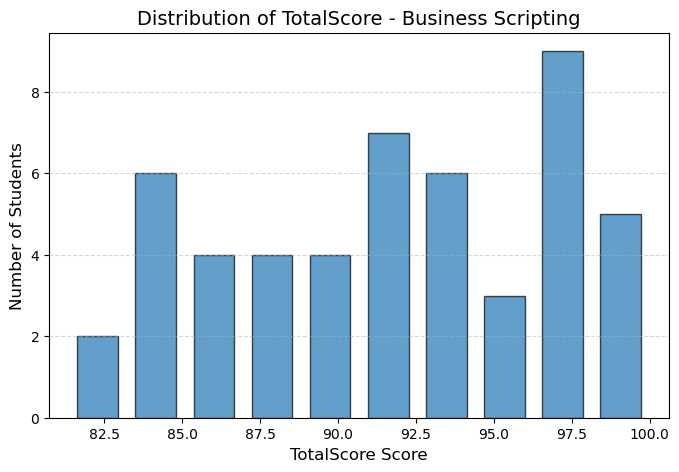


Showing distribution for: Machine Learning


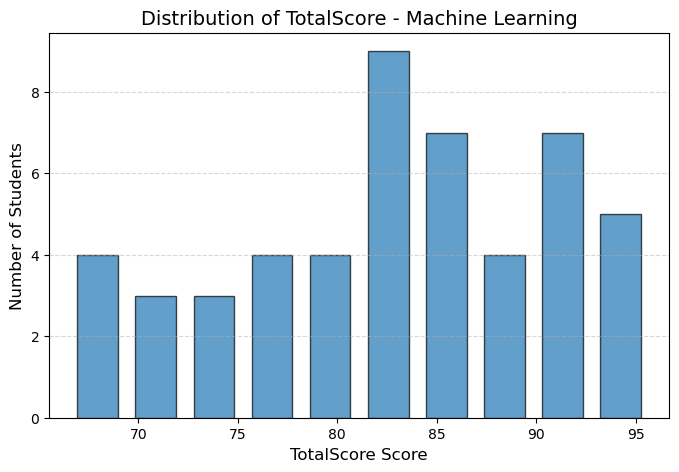

Finished plotting score distributions. Returning to menu...

Grade Management System

1. Enter new student data (manual)
2. Load data from CSV file(s)
3. Show summary statistics (per subject + combined)
4. Plot score distribution (per subject, TotalScore)
5. Plot letter grade pie chart (per subject)
6. Search student details by Roll Number
7. Export grade summaries per subject to CSV
0. Exit
Enter your choice: 

 5



Plotting letter grade pie charts for each subject...

Showing grade distribution for: Business Scripting


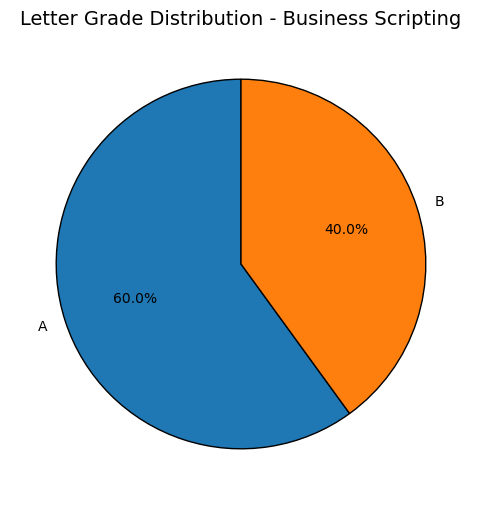


Showing grade distribution for: Machine Learning


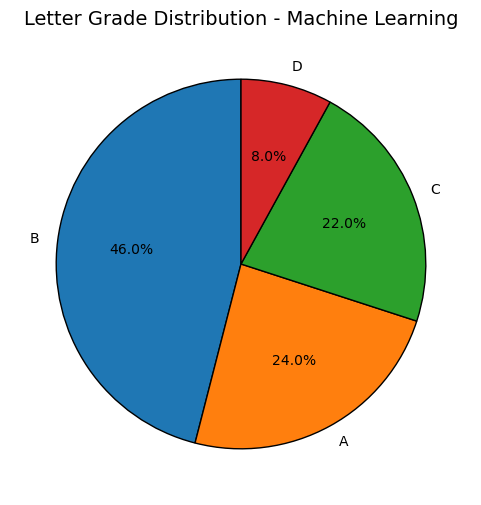

Finished plotting grade pies. Returning to menu...

Grade Management System

1. Enter new student data (manual)
2. Load data from CSV file(s)
3. Show summary statistics (per subject + combined)
4. Plot score distribution (per subject, TotalScore)
5. Plot letter grade pie chart (per subject)
6. Search student details by Roll Number
7. Export grade summaries per subject to CSV
0. Exit
Enter your choice: 

 6
Enter Student Roll Number to search:  20733467



Student Search Result

Subject: Business Scripting
 Student_ID Student_Name  Midterm_1  Midterm_2  Final_Exam  Missing Classes  TotalClasses  Threshold  TotalScore  AttendanceScore LetterGrade            Subject
   20733467   Shawn King        100         84         100                5            25          6        96.0            100.0           A Business Scripting

Grade Management System

1. Enter new student data (manual)
2. Load data from CSV file(s)
3. Show summary statistics (per subject + combined)
4. Plot score distribution (per subject, TotalScore)
5. Plot letter grade pie chart (per subject)
6. Search student details by Roll Number
7. Export grade summaries per subject to CSV
0. Exit
Enter your choice: 

 0


Go to main menu

    How would you like to start?
1. Import existing processed grade summary (e.g., grade_summary.csv)
2. Start fresh and load/process new subject scores
3. Exit.


Enter 1, 2 or 3:  3


Thank you for using the program, Goodbye!


In [208]:
main()